In [1]:
import sys
print(sys.executable)

/gpfs/data/brandeslab/User/as12267/.conda/envs/huggingface_bert_cu126/bin/python


In [2]:
import socket
import os

# Check hostname
hostname = socket.gethostname()
print(f"Hostname: {hostname}")

# Check if GPU is available
import torch
print(f"\nGPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Count: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

Hostname: a100-4005

GPU Available: True
GPU Count: 1
GPU Name: NVIDIA A100 80GB PCIe
CUDA Version: 12.6


In [1]:
import pandas as pd

In [4]:
clinvar_all_steps = pd.read_csv("clinvar_scores_all_steps.csv")
clinvar_all_steps

,step,variant_idx,pos,ref,alt,label,scored,ref_log_prob,alt_log_prob,log_odds,model_score
0,400,0,282,Q,P,1,True,-0.047540,-5.360040,-5.312500,5.312500
1,400,1,863,A,T,1,True,-0.110410,-3.954160,-3.843750,3.843750
2,400,2,286,G,V,1,True,-0.033995,-7.377745,-7.343750,7.343750
3,400,3,256,C,G,1,True,-0.016337,-5.250712,-5.234375,5.234375
4,400,4,264,Q,P,1,True,-7.424632,-6.018382,1.406250,-1.406250
...,...,...,...,...,...,...,...,...,...,...,...
1784410,6000,118956,960,G,D,1,False,NaN,NaN,NaN,NaN
1784411,6000,118957,574,G,E,1,False,NaN,NaN,NaN,NaN
1784412,6000,118958,342,R,C,1,True,-0.002070,-9.652461,-9.650391,9.650391
1784413,6000,118959,3940,W,R,1,False,NaN,NaN,NaN,NaN


In [6]:
num_scored = clinvar_all_steps.groupby("step")["scored"].sum()
print("Number of scored variants by step:")
print(num_scored)

Number of scored variants by step:
step
400     74713
800     74713
1200    74713
1600    74713
2000    74713
2400    74713
2800    74713
3200    74713
3600    74713
4000    74713
4400    74713
4800    74713
5200    74713
5600    74713
6000    74713
Name: scored, dtype: int64


In [7]:
clinvar_logits = pd.read_csv("clinvar_logits.csv")
clinvar_logits

,step,variant_idx,pos,ref,alt,label,scored,ref_log_prob,alt_log_prob,log_odds,...,prob_H,prob_S,prob_-,prob_R,prob_A,prob_Q,prob_V,prob_E,prob_T,prob_[PAD]
0,3400,0,282,Q,P,1,True,-0.013091,-7.177154,-7.164062,...,0.002604,0.000113,8.384114e-08,0.003910,0.000056,0.986994,0.000099,0.002093,0.000113,1.182351e-07
1,3400,1,863,A,T,1,True,-0.013706,-5.748081,-5.734375,...,0.000027,0.003139,3.798323e-09,0.000040,0.986387,0.000097,0.003342,0.000734,0.003189,3.148920e-09
2,3400,2,286,G,V,1,True,-0.009823,-7.814510,-7.804688,...,0.000055,0.001741,1.250268e-08,0.000992,0.001853,0.000182,0.000404,0.001796,0.000130,1.036508e-08
3,3400,3,256,C,G,1,True,-0.016300,-6.547550,-6.531250,...,0.000278,0.003777,6.715247e-08,0.006131,0.000371,0.000093,0.000273,0.000034,0.000226,4.912980e-08
4,3400,4,264,Q,P,1,True,-0.037415,-7.964173,-7.926758,...,0.005134,0.000610,7.149921e-09,0.005215,0.001239,0.963276,0.000500,0.006697,0.000592,1.335781e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237917,5200,118956,960,G,D,1,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237918,5200,118957,574,G,E,1,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
237919,5200,118958,342,R,C,1,True,-0.007338,-8.300307,-8.292969,...,0.000799,0.000956,5.506963e-10,0.992689,0.000818,0.000722,0.000268,0.000235,0.000231,8.012584e-10
237920,5200,118959,3940,W,R,1,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("clinvar_logits.csv")
df = df[df['scored']].copy()

# Pull p(ref) and p(alt) by indexing the prob_<AA> column named by the row's ref/alt
p_ref = df.apply(lambda r: r[f"prob_{r['ref']}"], axis=1)
p_alt = df.apply(lambda r: r[f"prob_{r['alt']}"], axis=1)

# log_odds = log p(alt) - log p(ref); model_score is the negation
recomputed_log_odds   = np.log(p_alt) - np.log(p_ref)
recomputed_model_score = -recomputed_log_odds

print((recomputed_log_odds - df['log_odds']).abs().max())
print((recomputed_model_score - df['model_score']).abs().max())

6.245592594211757e-07
6.245592594211757e-07


/tmp/ipykernel_1872291/1098380112.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_auroc)


Number of (ref,alt) pairs with enough samples: 135
Peak AUROC distribution across pairs:
count    135.000000
mean       0.676637
std        0.087169
min        0.428604
10%        0.560925
25%        0.625212
50%        0.681374
75%        0.734302
90%        0.798597
max        0.862066
Name: auroc, dtype: float64

Pairs with AUROC in [0.45, 0.55] (near random): 9/135
Pairs with AUROC > 0.85 (strong):                4/135
Sample-size-weighted mean AUROC: 0.6780


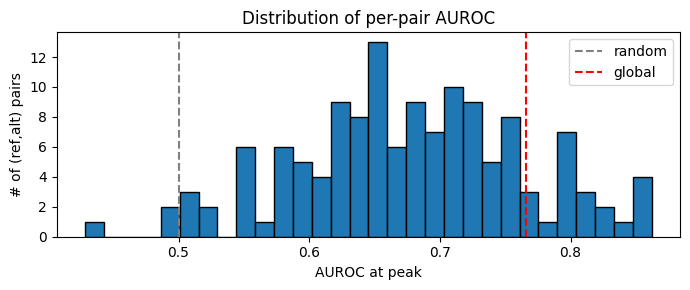


=== AUROC at peak by position decile ===
                    auroc       n
pos_bucket                       
(-0.001, 47.0]   0.772441  7478.0
(47.0, 97.0]     0.767873  7473.0
(97.0, 148.0]    0.783829  7466.0
(148.0, 202.0]   0.777253  7596.0
(202.0, 259.0]   0.760469  7399.0
(259.0, 321.0]   0.779142  7448.0
(321.0, 396.0]   0.772242  7467.0
(396.0, 489.0]   0.757476  7505.0
(489.0, 628.0]   0.759042  7428.0
(628.0, 1021.0]  0.747721  7453.0

=== AUROC at peak by reference confidence ===
                 auroc        n
p_ref_bucket                   
<0.5               NaN    160.0
0.5-0.9       0.694476   1639.0
0.9-0.99      0.732869  47225.0
0.99-0.999    0.719591  25602.0
>0.999             NaN     87.0


/tmp/ipykernel_1872291/1098380112.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({'auroc': safe_auroc(g, 100), 'n': len(g)})))
/tmp/ipykernel_1872291/1098380112.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({'auroc': safe_auroc(g, 100), 'n': len(g)})))


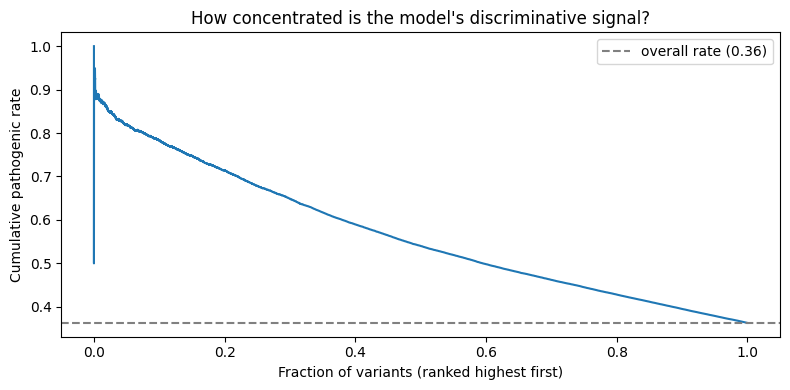

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


"""
What the subset hypothesis claimed. That the model's global AUROC of ~0.77 is an average that hides a split — some kinds of variants where the model truly discriminates (AUROC near 0.9), 
and other kinds where it's essentially guessing (AUROC near 0.5). The 0.77 would then be a misleading summary of two very different regimes.

sliced the data by (ref, alt) pair — 135 pairs with enough samples — and computed AUROC within each pair separately. 
Each pair's AUROC tells  how well the model ranks pathogenic above benign for that specific substitution type, in isolation.

"""

# ---- Use the peak checkpoint only ----
scores = pd.read_csv("clinvar_scores_all_steps.csv")
peak = scores[scores['scored'] & (scores['step'] == 3200)].copy()

# Pull peak-checkpoint p_ref from logits file
logits = pd.read_csv("clinvar_logits.csv")
peak_step_in_logits = 3400 if 3400 in logits['step'].unique() else 3200
lg = logits[logits['scored'] & (logits['step'] == peak_step_in_logits)].copy()
lg['p_ref'] = lg.apply(lambda r: r[f"prob_{r['ref']}"], axis=1)
peak = peak.merge(lg[['variant_idx', 'p_ref']], on='variant_idx', how='left')

# ---- 1. Distribution of AUROC across (ref, alt) pairs at peak ----
def safe_auroc(g, min_per_class=20):
    if (g['label']==0).sum() < min_per_class or (g['label']==1).sum() < min_per_class:
        return np.nan
    return roc_auc_score(g['label'], g['model_score'])

pair_auc = (peak.groupby(['ref','alt'])
                .apply(safe_auroc)
                .dropna()
                .rename('auroc')
                .reset_index())
pair_auc['n'] = peak.groupby(['ref','alt']).size().reindex(
    list(zip(pair_auc['ref'], pair_auc['alt']))).values

print(f"Number of (ref,alt) pairs with enough samples: {len(pair_auc)}")
print(f"Peak AUROC distribution across pairs:")
print(pair_auc['auroc'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

near_random = ((pair_auc['auroc'] > 0.45) & (pair_auc['auroc'] < 0.55)).sum()
strong = (pair_auc['auroc'] > 0.85).sum()
print(f"\nPairs with AUROC in [0.45, 0.55] (near random): {near_random}/{len(pair_auc)}")
print(f"Pairs with AUROC > 0.85 (strong):                {strong}/{len(pair_auc)}")
print(f"Sample-size-weighted mean AUROC: {(pair_auc['auroc']*pair_auc['n']).sum()/pair_auc['n'].sum():.4f}")

plt.figure(figsize=(7,3))
plt.hist(pair_auc['auroc'], bins=30, edgecolor='black')
plt.axvline(0.5, color='gray', linestyle='--', label='random')
plt.axvline(roc_auc_score(peak['label'], peak['model_score']), color='red', linestyle='--', label='global')
plt.xlabel('AUROC at peak'); plt.ylabel('# of (ref,alt) pairs'); plt.legend()
plt.title('Distribution of per-pair AUROC')
plt.tight_layout(); plt.show()

# ---- 2. By position decile ----
peak['pos_bucket'] = pd.qcut(peak['pos'], q=10, duplicates='drop')
print("\n=== AUROC at peak by position decile ===")
print(peak.groupby('pos_bucket', observed=True)
          .apply(lambda g: pd.Series({'auroc': safe_auroc(g, 100), 'n': len(g)})))

# ---- 3. By reference confidence at peak ----
peak['p_ref_bucket'] = pd.cut(peak['p_ref'], bins=[0, 0.5, 0.9, 0.99, 0.999, 1.0001],
                              labels=['<0.5','0.5-0.9','0.9-0.99','0.99-0.999','>0.999'])
print("\n=== AUROC at peak by reference confidence ===")
print(peak.groupby('p_ref_bucket', observed=True)
          .apply(lambda g: pd.Series({'auroc': safe_auroc(g, 100), 'n': len(g)})))

# ---- 4. Cumulative pathogenic rate plot ----
sorted_peak = peak.sort_values('model_score', ascending=False).reset_index(drop=True)
sorted_peak['cum_patho_rate'] = sorted_peak['label'].cumsum() / (sorted_peak.index + 1)

plt.figure(figsize=(8,4))
plt.plot(np.arange(len(sorted_peak))/len(sorted_peak), sorted_peak['cum_patho_rate'])
plt.axhline(peak['label'].mean(), color='gray', linestyle='--',
            label=f'overall rate ({peak["label"].mean():.2f})')
plt.xlabel('Fraction of variants (ranked highest first)')
plt.ylabel('Cumulative pathogenic rate')
plt.title("How concentrated is the model's discriminative signal?")
plt.legend(); plt.tight_layout(); plt.show()

In [16]:
import pandas as pd
import numpy as np

logits = pd.read_csv("clinvar_logits.csv")

# Convert log probabilities back to probabilities
logits["ref_prob"] = np.exp(logits["ref_log_prob"])
logits["alt_prob"] = np.exp(logits["alt_log_prob"])

summary = (
    logits
    .groupby("step")
    .agg(
        mean_ref_prob=("ref_prob", "mean"),
        median_ref_prob=("ref_prob", "median"),
        mean_alt_prob=("alt_prob", "mean"),
        median_alt_prob=("alt_prob", "median"),
        n_variants=("variant_idx", "count"),
    )
    .reset_index()
)

display(summary)

,step,mean_ref_prob,median_ref_prob,mean_alt_prob,median_alt_prob,n_variants
0,3400,0.977596,0.986565,0.004358,0.001883,118961
1,5200,0.986952,0.995994,0.002470,0.000510,118961


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

scores = pd.read_csv("clinvar_scores_all_steps.csv")

# log_odds = alt_log_prob - ref_log_prob
# model_score = -log_odds
# model_score = ref_log_prob - alt_log_prob
# benign_mean_score = mean(model_score for variants where label == 0)
# pathogenic_mean_score = mean(ref_log_prob - alt_log_prob for pathogenic variants)

summary = (
    scores
    .groupby(["step", "label"])
    .agg(
        mean_score=("model_score", "mean"),
        n_variants=("model_score", "size"),
    )
    .reset_index()
)

summary_wide = (
    summary
    .pivot(index="step", columns="label", values=["mean_score", "n_variants"])
)

summary_wide.columns = [
    "benign_mean_score",
    "pathogenic_mean_score",
    "n_benign",
    "n_pathogenic",
]

summary_wide = summary_wide.reset_index()

summary_wide["gap"] = (
    summary_wide["pathogenic_mean_score"] 
    - summary_wide["benign_mean_score"]
)

display(summary_wide)

,step,benign_mean_score,pathogenic_mean_score,n_benign,n_pathogenic,gap
0,400,4.744712,5.797453,81383.0,37578.0,1.052741
1,800,5.341970,6.367048,81383.0,37578.0,1.025078
2,1200,5.416475,6.523590,81383.0,37578.0,1.107115
3,1600,5.572324,6.663718,81383.0,37578.0,1.091394
4,2000,5.504610,6.547707,81383.0,37578.0,1.043098
5,2400,5.583589,6.715535,81383.0,37578.0,1.131946
6,2800,5.713467,6.778012,81383.0,37578.0,1.064544
7,3200,5.704959,6.975123,81383.0,37578.0,1.270164
8,3600,5.835974,6.935116,81383.0,37578.0,1.099142
9,4000,5.979762,7.036465,81383.0,37578.0,1.056702


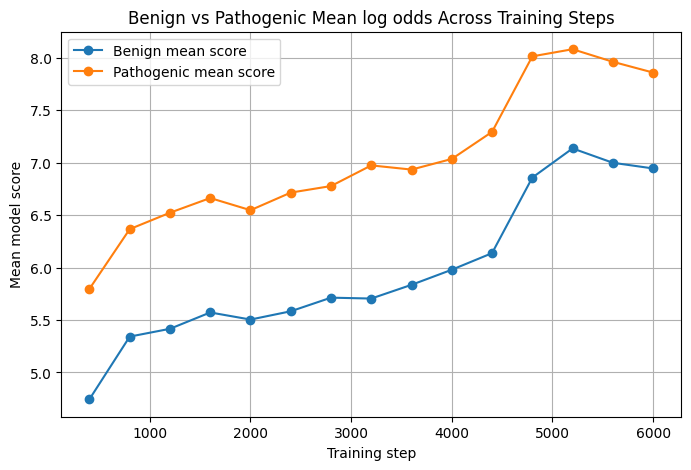

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(summary_wide["step"], summary_wide["benign_mean_score"], marker="o", label="Benign mean score")
plt.plot(summary_wide["step"], summary_wide["pathogenic_mean_score"], marker="o", label="Pathogenic mean score")
plt.xlabel("Training step")
plt.ylabel("Mean model score")
plt.title("Benign vs Pathogenic Mean log odds Across Training Steps")
plt.legend()
plt.grid(True)
plt.show()

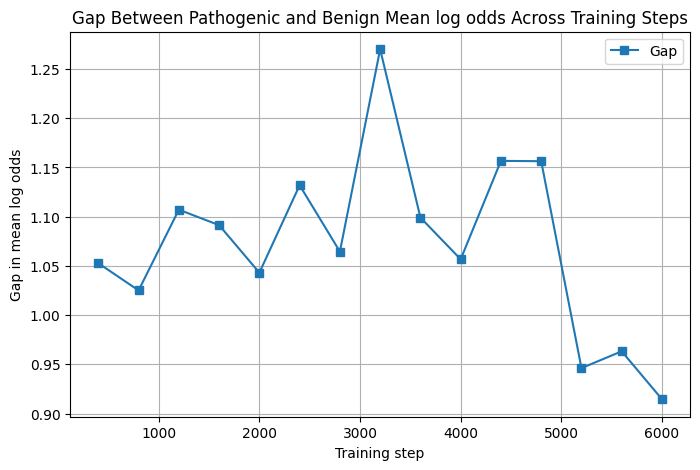

In [32]:
plt.figure(figsize=(8, 5))
# plt.plot(summary_wide["step"], summary_wide["benign_mean_score"], marker="o", label="Benign mean score")
# plt.plot(summary_wide["step"], summary_wide["pathogenic_mean_score"], marker="o", label="Pathogenic mean score")
plt.plot(summary_wide["step"], summary_wide["gap"], marker="s", label="Gap")
plt.xlabel("Training step")
plt.ylabel("Gap in mean log odds")
plt.title("Gap Between Pathogenic and Benign Mean log odds Across Training Steps")
plt.legend()
plt.grid(True)
plt.show()

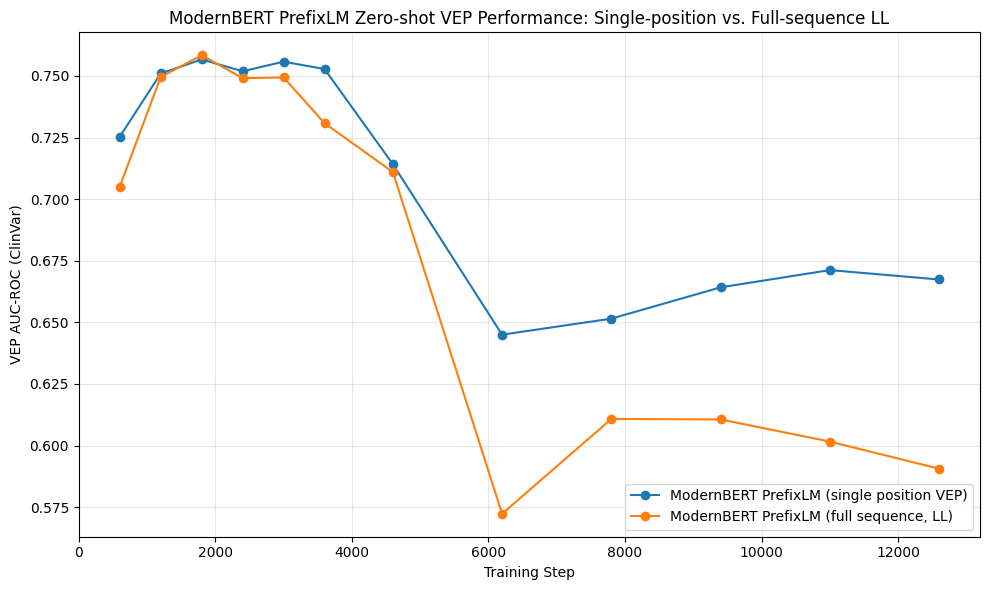

In [ ]:
import matplotlib.pyplot as plt

modernBERT_prefixlm_single_pos = {
    "600":0.7253,
    "1200":0.7510,
    "1800":0.7567,
    "2400":0.7519,
    "3000":0.7558, 
    "3600":0.7528, 
    "4600":0.7142, 
    "6200":0.6450,
    "7800":0.6515,
    "9400":0.6642,
    "11000":0.6712, 
    "12600":0.6674,

}   


modernBERT_prefixlm_full_seq_LL = {
    "600":0.7051,
    "1200":0.7496,
    "1800":0.7584,
    "2400":0.7491,
    "3000":0.7494, 
    "3600":0.7308,
    "4600":0.7110,
    "6200":0.5723, 
    "7800":0.6108, 
    "9400":0.6106,
    "11000":0.6016, 
    "12600":0.5906

}  



def sort_xy(d):
    x = sorted(int(k) for k in d.keys())
    y = [d[str(step)] for step in x]
    return x, y

x1, y1 = sort_xy(modernBERT_prefixlm_single_pos)
x2, y2 = sort_xy(modernBERT_prefixlm_full_seq_LL)

plt.figure(figsize=(10, 6))
plt.plot(x1, y1, marker='o', label='ModernBERT PrefixLM (single position VEP)')
plt.plot(x2, y2, marker='o', label='ModernBERT PrefixLM (full sequence, LL)')

plt.xlabel("Training Step")
plt.ylabel("VEP AUC-ROC (ClinVar)")
plt.title("ModernBERT PrefixLM Zero-shot VEP Performance: Single-position vs. Full-sequence LL")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
import numpy as np

scores = pd.read_csv("clinvar_scores_all_steps.csv")
scored = scores[scores['scored']].copy()

summary = scored.groupby('step').agg(
    mean_ref_logprob = ('ref_log_prob', 'mean'),
    mean_p_ref       = ('ref_log_prob', lambda x: np.exp(x).mean()),
).reset_index()

print(summary.to_string(index=False))

 step  mean_ref_logprob  mean_p_ref
  400         -0.412117    0.827832
  800         -0.057887    0.955818
 1200         -0.048328    0.961555
 1600         -0.037456    0.968787
 2000         -0.035747    0.969010
 2400         -0.033916    0.970328
 2800         -0.030377    0.973462
 3200         -0.030000    0.973618
 3600         -0.026273    0.976678
 4000         -0.025635    0.977981
 4400         -0.021784    0.980980
 4800         -0.017062    0.985923
 5200         -0.015895    0.986952
 5600         -0.015464    0.986418
 6000         -0.017045    0.985556


In [ ]:
# entropy  
# sift score (what extra does the mdoel learn beyond conservation which is important for VEP)


In [44]:
import pandas as pd
from gLM.tokenizers import PhyloTokenizerLoader
TOKENIZER  = "./phylo_char_tokenizer_with_bos"

tokenizer = PhyloTokenizerLoader(TOKENIZER)

max_len = 2048
clinvar_csv = pd.read_csv("/gpfs/data/brandeslab/Data/clinvar_AA_zero_shot_input.csv")

def apply_same_prefixlm_filters(df, tokenizer, max_len=2048):
    keep = []
    reasons = []

    cls_id = tokenizer.cls_token_id
    sep_id = tokenizer.sep_token_id

    for i, row in df.iterrows():
        seq = row["sequence"]
        pos = int(row["pos"])
        ref = row["ref"]
        alt = row["alt"]

        # Filter 1: same initial check
        if len(seq) > max_len:
            keep.append(False)
            reasons.append("seq_len_gt_max")
            continue

        # Filter 2: valid position
        if pos >= len(seq):
            keep.append(False)
            reasons.append("pos_out_of_bounds")
            continue

        # Filter 3: reference allele must match sequence
        if seq[pos] != ref:
            keep.append(False)
            reasons.append("ref_mismatch")
            continue

        # Filter 4: ref/alt must exist in tokenizer
        ref_id = tokenizer.convert_tokens_to_ids(ref)
        alt_id = tokenizer.convert_tokens_to_ids(alt)

        if ref_id is None or alt_id is None:
            keep.append(False)
            reasons.append("token_missing")
            continue

        # Optional safer check: tokenizer may return unk id instead of None
        if ref_id == tokenizer.unk_token_id or alt_id == tokenizer.unk_token_id:
            keep.append(False)
            reasons.append("token_unk")
            continue

        # Filter 5: packed PrefixLM length
        enc_full = tokenizer(seq, add_special_tokens=False)["input_ids"]
        enc_prefix = enc_full
        enc_suffix = enc_full[:pos]

        packed_len = 1 + len(enc_prefix) + 1 + len(enc_suffix) + 1
        # [CLS] + full seq + [SEP] + seq[:pos] + [SEP]

        if packed_len > max_len:
            keep.append(False)
            reasons.append("packed_len_gt_max")
            continue

        keep.append(True)
        reasons.append("kept")

    out = df.copy()
    out["prefixlm_keep"] = keep
    out["filter_reason"] = reasons
    return out


filtered = apply_same_prefixlm_filters(clinvar_csv, tokenizer, max_len=max_len)

print("Total original variants:", len(filtered))
print("Total kept:", filtered["prefixlm_keep"].sum())

print("\nKept variants per label:")
print(filtered.loc[filtered["prefixlm_keep"], "label"].value_counts())

print("\nDropped variants per reason:")
print(filtered["filter_reason"].value_counts())

print("\nDropped variants per reason and label:")
print(pd.crosstab(filtered["filter_reason"], filtered["label"]))

/gpfs/data/brandeslab/User/as12267/.conda/envs/huggingface_bert_cu126/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total original variants: 118961
Total kept: 74713

Kept variants per label:
label
0    47591
1    27122
Name: count, dtype: int64

Dropped variants per reason:
filter_reason
kept                 74713
seq_len_gt_max       27365
packed_len_gt_max    16883
Name: count, dtype: int64

Dropped variants per reason and label:
label                  0      1
filter_reason                  
kept               47591  27122
packed_len_gt_max  11756   5127
seq_len_gt_max     22036   5329


## PrefixLM (trained on unaligned sequences)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def compute_auc(group):
    return roc_auc_score(group["label"], group["model_score"])


In [9]:
unaligned_clinvar_entropy = pd.read_csv("/gpfs/data/brandeslab/User/as12267/modernBERT_113M_prefixlm_bs512_ctxt_2048_100k_final_single_pos/clinvar_full_dist_entropy.csv")
# Keep only successfully scored variants with valid scores and labels
unaligned_clinvar_entropy = unaligned_clinvar_entropy[
    unaligned_clinvar_entropy["scored"]
    & unaligned_clinvar_entropy["model_score"].notna()
    & unaligned_clinvar_entropy["label"].notna()
]

vep_auc = unaligned_clinvar_entropy.groupby("step").apply(compute_auc)
unaligned_clinvar_entropy["AUC"] = unaligned_clinvar_entropy["step"].map(vep_auc)
print(f"VEP AUROC at each step:\n{vep_auc}")


VEP AUROC at each step:
step
400     0.673516
800     0.731095
1200    0.750983
1600    0.752802
2000    0.751158
2400    0.751897
2800    0.742294
3200    0.766194
3600    0.752918
4000    0.742869
4400    0.753938
4800    0.728770
5200    0.682705
5600    0.682150
6000    0.676686
dtype: float64


/tmp/ipykernel_4086475/1665496259.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vep_auc = unaligned_clinvar_entropy.groupby("step").apply(compute_auc)


Number of scored variants by step:
step
400     74713
800     74713
1200    74713
1600    74713
2000    74713
2400    74713
2800    74713
3200    74713
3600    74713
4000    74713
4400    74713
4800    74713
5200    74713
5600    74713
6000    74713
Name: scored, dtype: int64


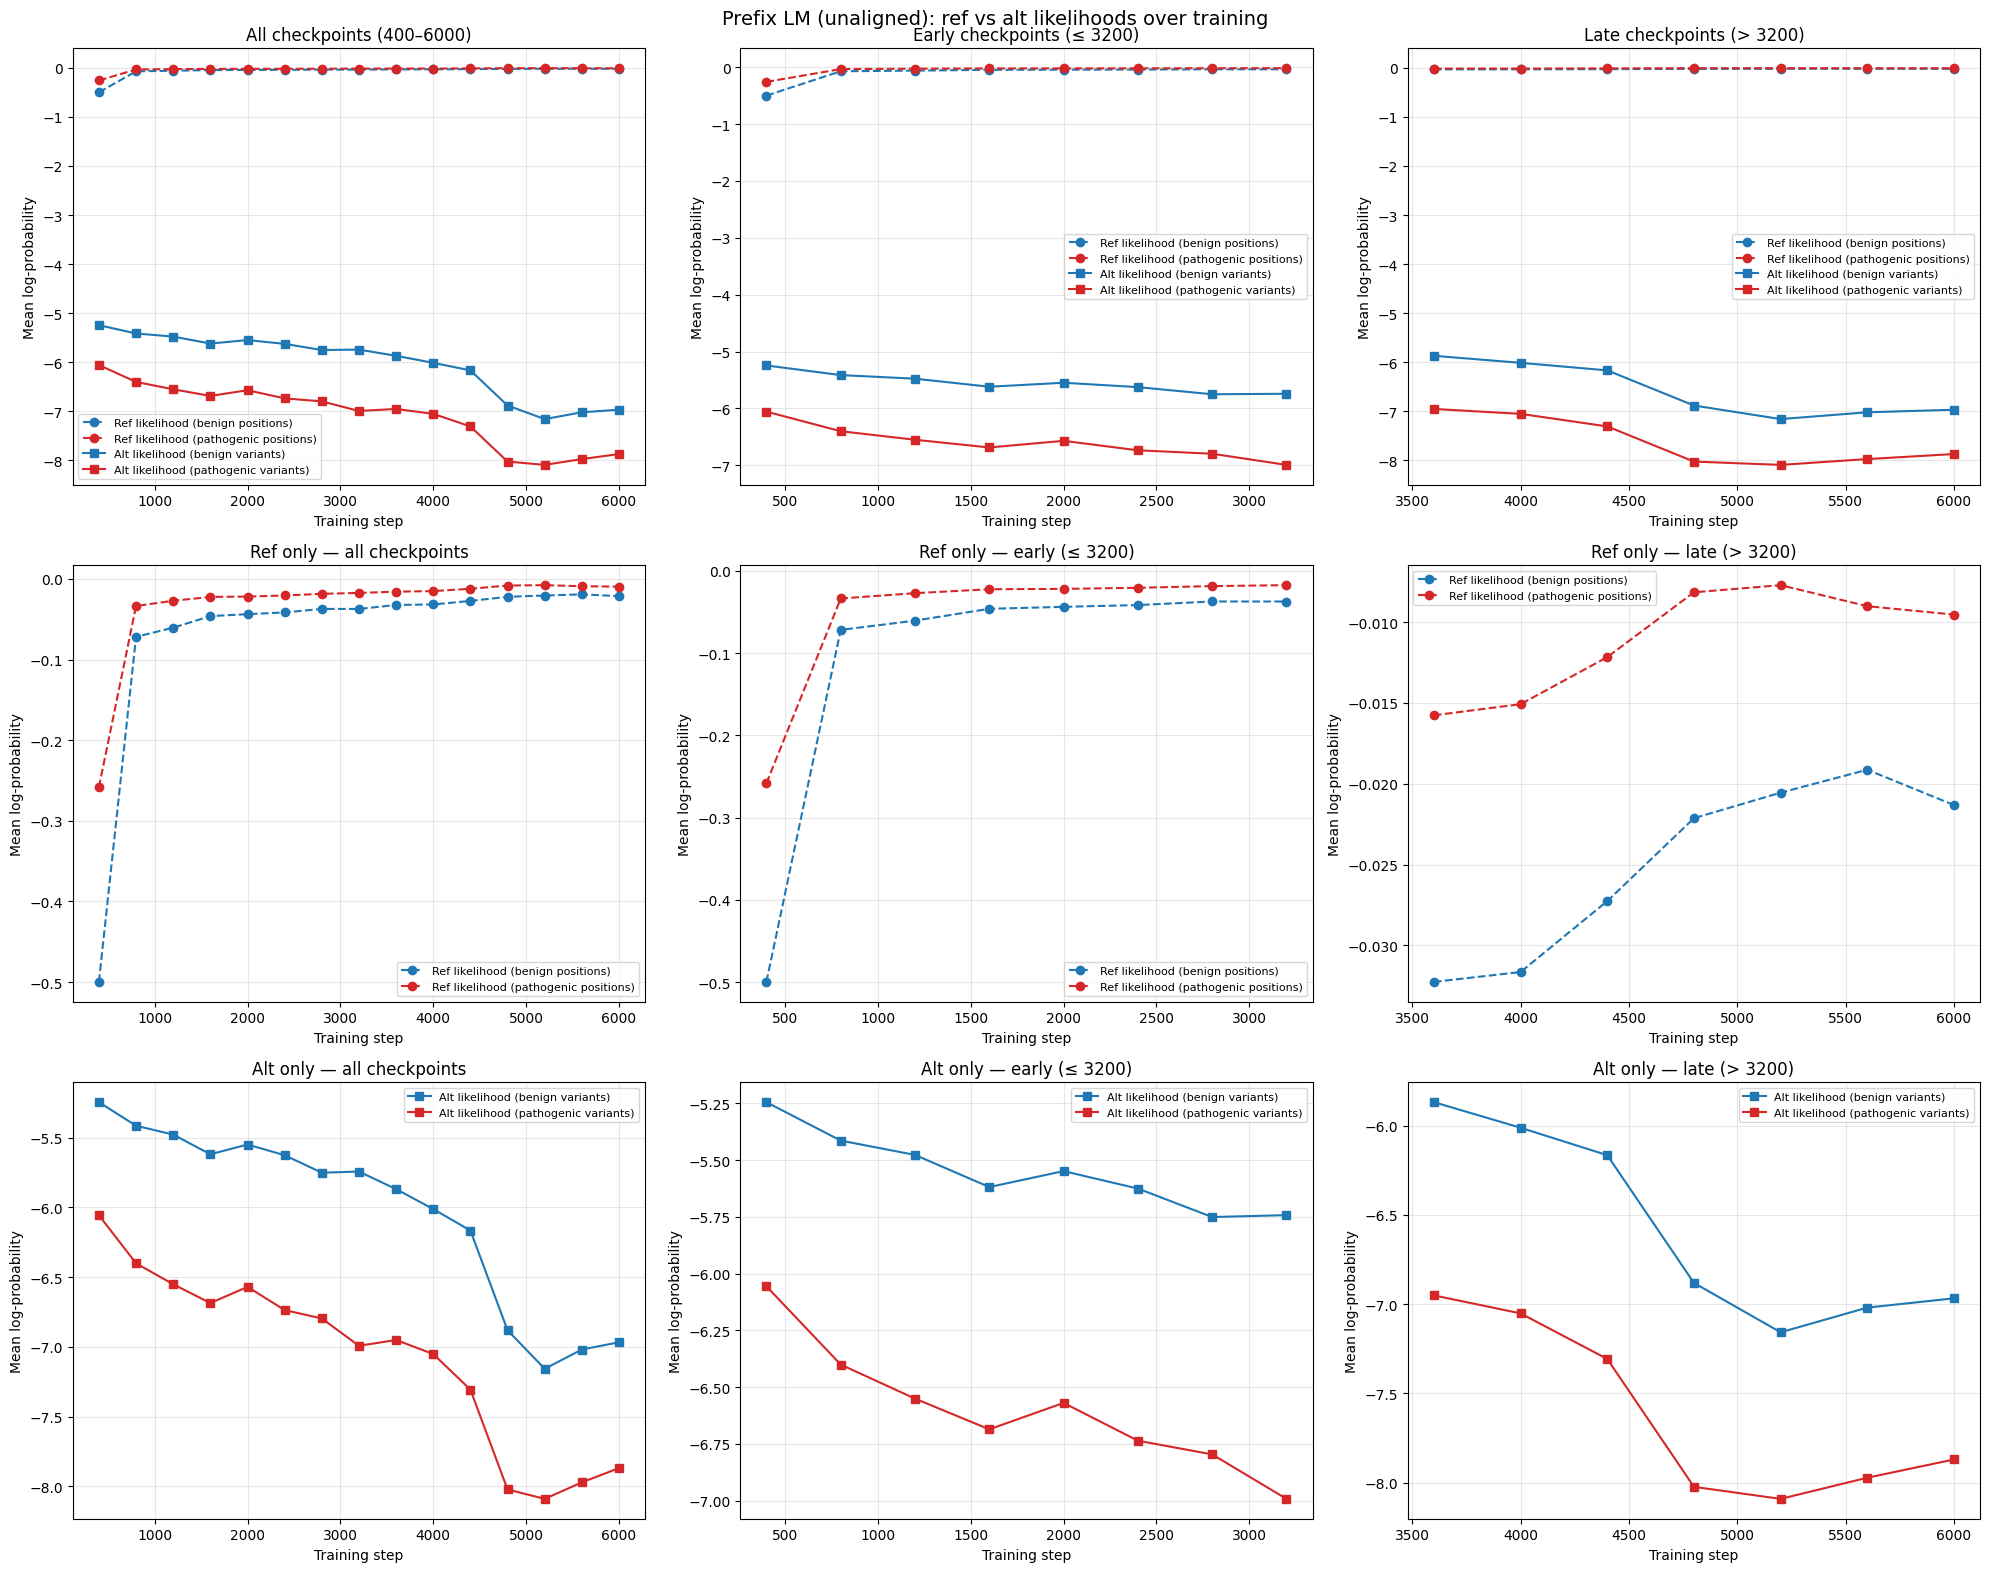

,ref_benign,ref_pathogenic,alt_benign,alt_pathogenic,benign_minus_pathogenic_alt
step,,,,,
400,-0.4998,-0.2583,-5.2445,-6.0558,0.8113
800,-0.0718,-0.0335,-5.4137,-6.4006,0.9869
1200,-0.0604,-0.0271,-5.4769,-6.5507,1.0737
1600,-0.0461,-0.0223,-5.6184,-6.6860,1.0676
2000,-0.0437,-0.0218,-5.5483,-6.5696,1.0213
2400,-0.0415,-0.0205,-5.6251,-6.7361,1.1109
2800,-0.0372,-0.0185,-5.7506,-6.7965,1.0458
3200,-0.0372,-0.0173,-5.7422,-6.9925,1.2503
3600,-0.0323,-0.0158,-5.8682,-6.9509,1.0827


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

num_scored = unaligned_clinvar_entropy.groupby("step")["scored"].sum()
print("Number of scored variants by step:")
print(num_scored)

# Label convention: 1 = pathogenic, 0 = benign
benign = unaligned_clinvar_entropy[unaligned_clinvar_entropy["label"] == 0]
pathogenic = unaligned_clinvar_entropy[unaligned_clinvar_entropy["label"] == 1]

ref_benign      = benign.groupby("step")["ref_log_prob"].mean()
ref_pathogenic  = pathogenic.groupby("step")["ref_log_prob"].mean()
alt_benign      = benign.groupby("step")["alt_log_prob"].mean()
alt_pathogenic  = pathogenic.groupby("step")["alt_log_prob"].mean()


def plot_curves(ax, ref_b, ref_p, alt_b, alt_p, title):
    ax.plot(ref_b.index, ref_b.values,
            label="Ref likelihood (benign positions)",
            color="tab:blue", linestyle="--", marker="o")
    ax.plot(ref_p.index, ref_p.values,
            label="Ref likelihood (pathogenic positions)",
            color="tab:red", linestyle="--", marker="o")
    ax.plot(alt_b.index, alt_b.values,
            label="Alt likelihood (benign variants)",
            color="tab:blue", linestyle="-", marker="s")
    ax.plot(alt_p.index, alt_p.values,
            label="Alt likelihood (pathogenic variants)",
            color="tab:red", linestyle="-", marker="s")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean log-probability")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)


def plot_ref_only(ax, ref_b, ref_p, title):
    ax.plot(ref_b.index, ref_b.values,
            label="Ref likelihood (benign positions)",
            color="tab:blue", linestyle="--", marker="o")
    ax.plot(ref_p.index, ref_p.values,
            label="Ref likelihood (pathogenic positions)",
            color="tab:red", linestyle="--", marker="o")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean log-probability")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)


def plot_alt_only(ax, alt_b, alt_p, title):
    ax.plot(alt_b.index, alt_b.values,
            label="Alt likelihood (benign variants)",
            color="tab:blue", linestyle="-", marker="s")
    ax.plot(alt_p.index, alt_p.values,
            label="Alt likelihood (pathogenic variants)",
            color="tab:red", linestyle="-", marker="s")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean log-probability")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)


mask_early = ref_benign.index <= 3200
mask_late = ref_benign.index > 3200

fig, axes = plt.subplots(3, 3, figsize=(20, 16))

# Row 1: combined ref + alt
plot_curves(axes[0, 0], ref_benign, ref_pathogenic, alt_benign, alt_pathogenic,
            "All checkpoints (400–6000)")
plot_curves(axes[0, 1],
            ref_benign[mask_early], ref_pathogenic[mask_early],
            alt_benign[mask_early], alt_pathogenic[mask_early],
            "Early checkpoints (≤ 3200)")
plot_curves(axes[0, 2],
            ref_benign[mask_late], ref_pathogenic[mask_late],
            alt_benign[mask_late], alt_pathogenic[mask_late],
            "Late checkpoints (> 3200)")

# Row 2: ref only
plot_ref_only(axes[1, 0], ref_benign, ref_pathogenic,
              "Ref only — all checkpoints")
plot_ref_only(axes[1, 1], ref_benign[mask_early], ref_pathogenic[mask_early],
              "Ref only — early (≤ 3200)")
plot_ref_only(axes[1, 2], ref_benign[mask_late], ref_pathogenic[mask_late],
              "Ref only — late (> 3200)")

# Row 3: alt only
plot_alt_only(axes[2, 0], alt_benign, alt_pathogenic,
              "Alt only — all checkpoints")
plot_alt_only(axes[2, 1], alt_benign[mask_early], alt_pathogenic[mask_early],
              "Alt only — early (≤ 3200)")
plot_alt_only(axes[2, 2], alt_benign[mask_late], alt_pathogenic[mask_late],
              "Alt only — late (> 3200)")

plt.suptitle("Prefix LM (unaligned): ref vs alt likelihoods over training", fontsize=14)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "ref_benign": ref_benign,
    "ref_pathogenic": ref_pathogenic,
    "alt_benign": alt_benign,
    "alt_pathogenic": alt_pathogenic,
})
summary["benign_minus_pathogenic_alt"] = summary["alt_benign"] - summary["alt_pathogenic"]
summary.round(4)

/tmp/ipykernel_4086475/1248362734.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vep_auc = unaligned_clinvar_entropy.groupby("step").apply(compute_auc)


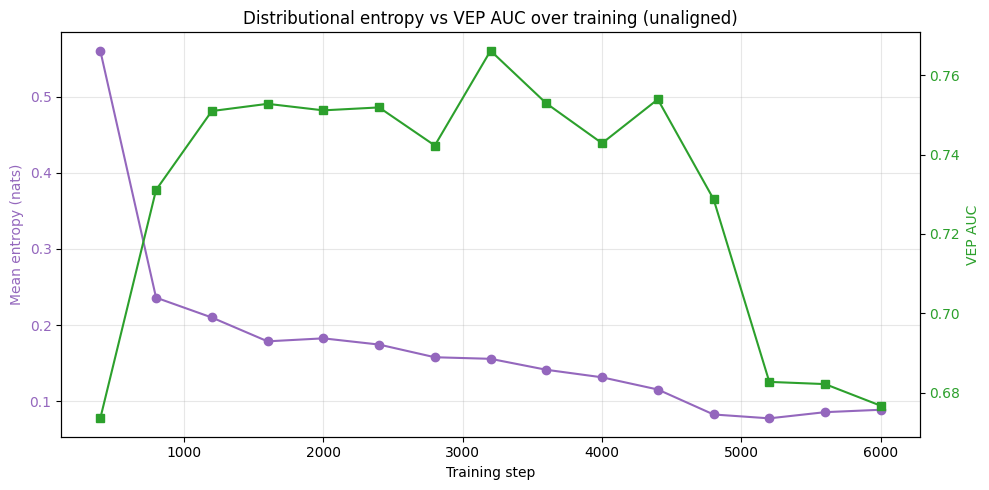

      mean_entropy  vep_auc
step                       
400         0.5604   0.6735
800         0.2360   0.7311
1200        0.2100   0.7510
1600        0.1786   0.7528
2000        0.1826   0.7512
2400        0.1744   0.7519
2800        0.1577   0.7423
3200        0.1557   0.7662
3600        0.1413   0.7529
4000        0.1314   0.7429
4400        0.1154   0.7539
4800        0.0826   0.7288
5200        0.0775   0.6827
5600        0.0856   0.6821
6000        0.0887   0.6767


In [11]:
# Mean entropy per checkpoint
mean_entropy = unaligned_clinvar_entropy.groupby("step")["entropy"].mean()

# VEP AUC per checkpoint
def compute_auc(group):
    return roc_auc_score(group["label"], group["model_score"])

vep_auc = unaligned_clinvar_entropy.groupby("step").apply(compute_auc)

# Plot with twin axes
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(mean_entropy.index, mean_entropy.values,
         marker="o", color="tab:purple", label="Mean entropy")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean entropy (nats)", color="tab:purple")
ax1.tick_params(axis="y", labelcolor="tab:purple")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(vep_auc.index, vep_auc.values,
         marker="s", color="tab:green", label="VEP AUC")
ax2.set_ylabel("VEP AUC", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

plt.title("Distributional entropy vs VEP AUC over training (unaligned)")
fig.tight_layout()
plt.show()

summary = pd.DataFrame({"mean_entropy": mean_entropy, "vep_auc": vep_auc})
print(summary.round(4))

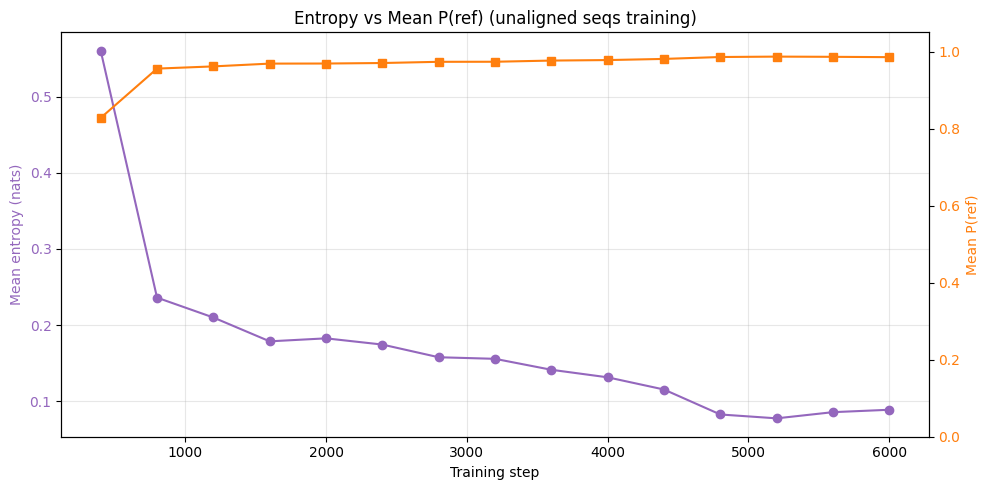

In [14]:
import numpy as np

mean_entropy = unaligned_clinvar_entropy.groupby("step")["entropy"].mean()
mean_p_ref = unaligned_clinvar_entropy.groupby("step")["ref_log_prob"].apply(lambda x: np.exp(x).mean())

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(mean_entropy.index, mean_entropy.values,
         marker="o", color="tab:purple", label="Mean entropy")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean entropy (nats)", color="tab:purple")
ax1.tick_params(axis="y", labelcolor="tab:purple")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(mean_p_ref.index, mean_p_ref.values,
         marker="s", color="tab:orange", label="Mean P(ref)")
ax2.set_ylabel("Mean P(ref)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0, 1.05)

plt.title("Entropy vs Mean P(ref) (unaligned seqs training)")
fig.tight_layout()
plt.show()

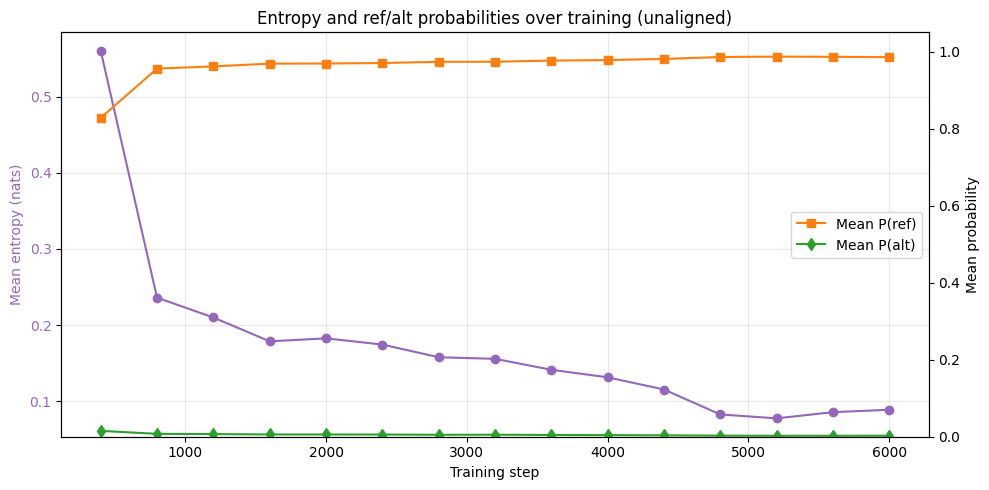

In [25]:
mean_entropy = unaligned_clinvar_entropy.groupby("step")["entropy"].mean()
mean_p_ref = unaligned_clinvar_entropy.groupby("step")["ref_log_prob"].apply(lambda x: np.exp(x).mean())
mean_p_alt = unaligned_clinvar_entropy.groupby("step")["alt_log_prob"].apply(lambda x: np.exp(x).mean())


fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(mean_entropy.index, mean_entropy.values,
         marker="o", color="tab:purple", label="Mean entropy (left axis)")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean entropy (nats)", color="tab:purple")
ax1.tick_params(axis="y", labelcolor="tab:purple")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(mean_p_ref.index, mean_p_ref.values,
         marker="s", color="tab:orange", label="Mean P(ref)")
ax2.plot(mean_p_alt.index, mean_p_alt.values,
         marker="d", color="tab:green", label="Mean P(alt)")
ax2.set_ylabel("Mean probability", color="black")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="center right")

plt.title("Entropy and ref/alt probabilities over training (unaligned)")
fig.tight_layout()
plt.show()

In [22]:
unaligned_clinvar_entropy.columns

Index(['step', 'variant_idx', 'pos', 'ref', 'alt', 'label', 'scored',
       'log_odds', 'model_score', 'ref_log_prob', 'alt_log_prob', 'entropy',
       'prob_W', 'prob_T', 'prob_E', 'prob_[MASK]', 'prob_H', 'prob_I',
       'prob_A', 'prob_[UNK]', 'prob_F', 'prob_L', 'prob_-', 'prob_[GAP]',
       'prob_[SEP]', 'prob_C', 'prob_[CLS]', 'prob_M', 'prob_R', 'prob_Q',
       'prob_G', 'prob_V', 'prob_Y', 'prob_[PAD]', 'prob_N', 'prob_P',
       'prob_K', 'prob_D', 'prob_S', 'seq_log_prob', 'seq_entropy', 'AUC'],
      dtype='object')

## PrefixLM (trained on aligned sequences)

In [16]:
aligned_clinvar_entropy = pd.read_csv("/gpfs/data/brandeslab/User/as12267/modernBERT_113M_prefixlm_aligned_bs512_ctxt_2048/clinvar_full_dist_entropy.csv")

# Keep only successfully scored variants with valid scores and labels
aligned_clinvar_entropy = aligned_clinvar_entropy[
    aligned_clinvar_entropy["scored"]
    & aligned_clinvar_entropy["model_score"].notna()
    & aligned_clinvar_entropy["label"].notna()
]

vep_auc = aligned_clinvar_entropy.groupby("step").apply(compute_auc)
aligned_clinvar_entropy["AUC"] = aligned_clinvar_entropy["step"].map(vep_auc)
print(f"VEP AUROC at each step:\n{vep_auc}")


VEP AUROC at each step:
step
500     0.661725
1000    0.722366
1500    0.719578
2000    0.727331
2500    0.731904
3000    0.732281
3500    0.725755
4000    0.732502
4500    0.735841
5000    0.732894
5500    0.735535
6000    0.738108
6500    0.733305
dtype: float64


/tmp/ipykernel_4086475/3278944522.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vep_auc = aligned_clinvar_entropy.groupby("step").apply(compute_auc)


Number of scored variants by step:
step
500     74713
1000    74713
1500    74713
2000    74713
2500    74713
3000    74713
3500    74713
4000    74713
4500    74713
5000    74713
5500    74713
6000    74713
6500    74713
Name: scored, dtype: int64


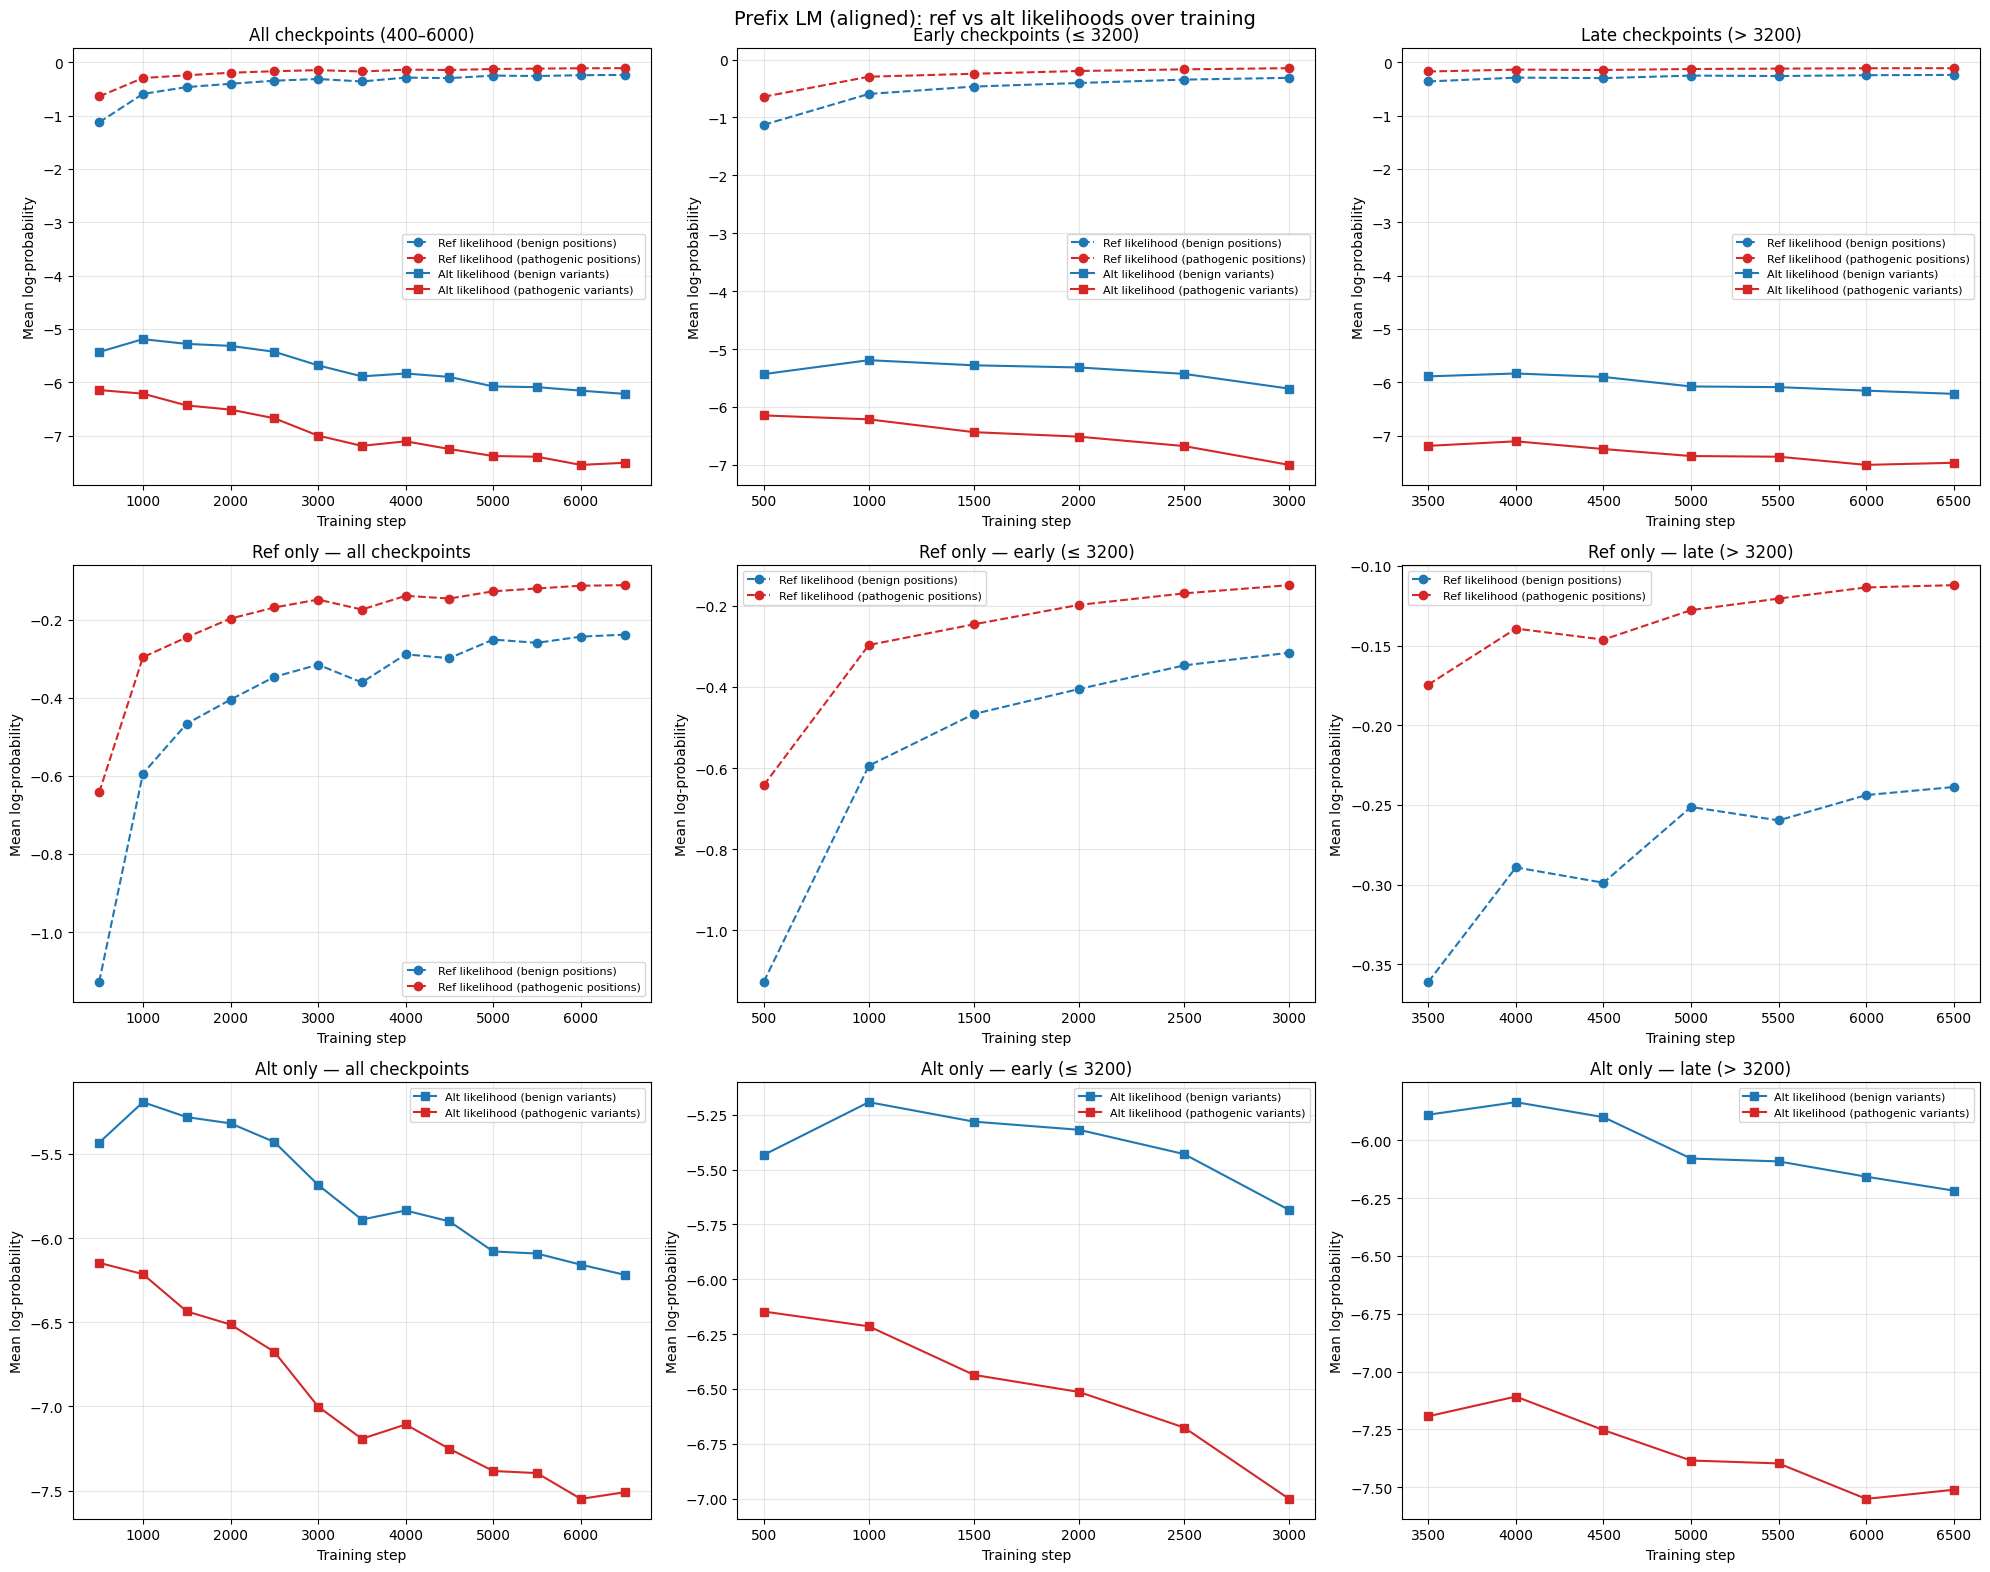

,ref_benign,ref_pathogenic,alt_benign,alt_pathogenic,benign_minus_pathogenic_alt
step,,,,,
500,-1.1273,-0.6423,-5.4329,-6.1469,0.7140
1000,-0.5942,-0.2964,-5.1924,-6.2143,1.0219
1500,-0.4667,-0.2455,-5.2811,-6.4357,1.1545
2000,-0.4050,-0.1976,-5.3183,-6.5135,1.1952
2500,-0.3468,-0.1692,-5.4290,-6.6757,1.2467
3000,-0.3155,-0.1489,-5.6838,-7.0010,1.3172
3500,-0.3610,-0.1745,-5.8902,-7.1928,1.3026
4000,-0.2892,-0.1393,-5.8360,-7.1077,1.2717
4500,-0.2988,-0.1463,-5.9008,-7.2525,1.3517


In [17]:

num_scored = aligned_clinvar_entropy.groupby("step")["scored"].sum()
print("Number of scored variants by step:")
print(num_scored)

# Label convention: 1 = pathogenic, 0 = benign
benign = aligned_clinvar_entropy[aligned_clinvar_entropy["label"] == 0]
pathogenic = aligned_clinvar_entropy[aligned_clinvar_entropy["label"] == 1]

ref_benign      = benign.groupby("step")["ref_log_prob"].mean()
ref_pathogenic  = pathogenic.groupby("step")["ref_log_prob"].mean()
alt_benign      = benign.groupby("step")["alt_log_prob"].mean()
alt_pathogenic  = pathogenic.groupby("step")["alt_log_prob"].mean()


def plot_curves(ax, ref_b, ref_p, alt_b, alt_p, title):
    ax.plot(ref_b.index, ref_b.values,
            label="Ref likelihood (benign positions)",
            color="tab:blue", linestyle="--", marker="o")
    ax.plot(ref_p.index, ref_p.values,
            label="Ref likelihood (pathogenic positions)",
            color="tab:red", linestyle="--", marker="o")
    ax.plot(alt_b.index, alt_b.values,
            label="Alt likelihood (benign variants)",
            color="tab:blue", linestyle="-", marker="s")
    ax.plot(alt_p.index, alt_p.values,
            label="Alt likelihood (pathogenic variants)",
            color="tab:red", linestyle="-", marker="s")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean log-probability")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)


def plot_ref_only(ax, ref_b, ref_p, title):
    ax.plot(ref_b.index, ref_b.values,
            label="Ref likelihood (benign positions)",
            color="tab:blue", linestyle="--", marker="o")
    ax.plot(ref_p.index, ref_p.values,
            label="Ref likelihood (pathogenic positions)",
            color="tab:red", linestyle="--", marker="o")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean log-probability")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)


def plot_alt_only(ax, alt_b, alt_p, title):
    ax.plot(alt_b.index, alt_b.values,
            label="Alt likelihood (benign variants)",
            color="tab:blue", linestyle="-", marker="s")
    ax.plot(alt_p.index, alt_p.values,
            label="Alt likelihood (pathogenic variants)",
            color="tab:red", linestyle="-", marker="s")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Mean log-probability")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)


mask_early = ref_benign.index <= 3200
mask_late = ref_benign.index > 3200

fig, axes = plt.subplots(3, 3, figsize=(20, 16))

# Row 1: combined ref + alt
plot_curves(axes[0, 0], ref_benign, ref_pathogenic, alt_benign, alt_pathogenic,
            "All checkpoints (400–6000)")
plot_curves(axes[0, 1],
            ref_benign[mask_early], ref_pathogenic[mask_early],
            alt_benign[mask_early], alt_pathogenic[mask_early],
            "Early checkpoints (≤ 3200)")
plot_curves(axes[0, 2],
            ref_benign[mask_late], ref_pathogenic[mask_late],
            alt_benign[mask_late], alt_pathogenic[mask_late],
            "Late checkpoints (> 3200)")

# Row 2: ref only
plot_ref_only(axes[1, 0], ref_benign, ref_pathogenic,
              "Ref only — all checkpoints")
plot_ref_only(axes[1, 1], ref_benign[mask_early], ref_pathogenic[mask_early],
              "Ref only — early (≤ 3200)")
plot_ref_only(axes[1, 2], ref_benign[mask_late], ref_pathogenic[mask_late],
              "Ref only — late (> 3200)")

# Row 3: alt only
plot_alt_only(axes[2, 0], alt_benign, alt_pathogenic,
              "Alt only — all checkpoints")
plot_alt_only(axes[2, 1], alt_benign[mask_early], alt_pathogenic[mask_early],
              "Alt only — early (≤ 3200)")
plot_alt_only(axes[2, 2], alt_benign[mask_late], alt_pathogenic[mask_late],
              "Alt only — late (> 3200)")

plt.suptitle("Prefix LM (aligned): ref vs alt likelihoods over training", fontsize=14)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "ref_benign": ref_benign,
    "ref_pathogenic": ref_pathogenic,
    "alt_benign": alt_benign,
    "alt_pathogenic": alt_pathogenic,
})
summary["benign_minus_pathogenic_alt"] = summary["alt_benign"] - summary["alt_pathogenic"]
summary.round(4)

/tmp/ipykernel_4086475/3908020228.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vep_auc = aligned_clinvar_entropy.groupby("step").apply(compute_auc)


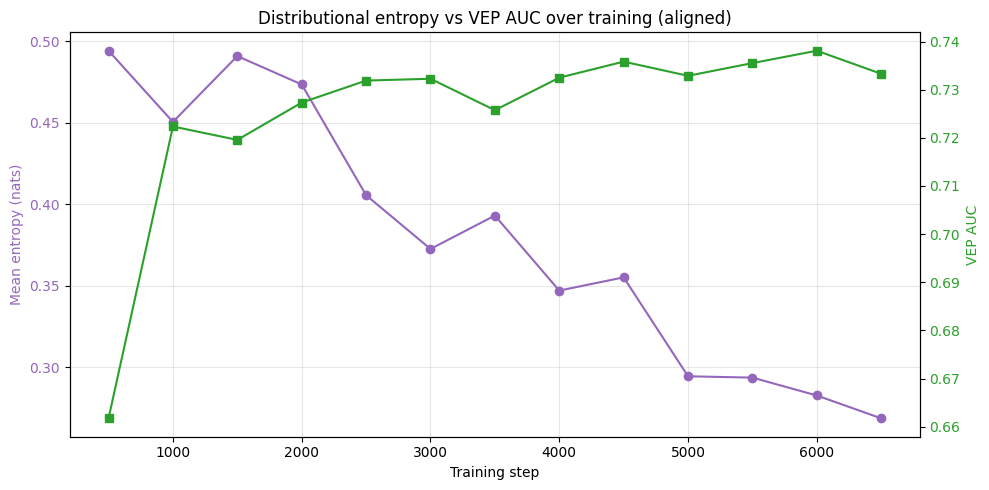

      mean_entropy  vep_auc
step                       
500         0.4942   0.6617
1000        0.4505   0.7224
1500        0.4909   0.7196
2000        0.4735   0.7273
2500        0.4055   0.7319
3000        0.3725   0.7323
3500        0.3930   0.7258
4000        0.3469   0.7325
4500        0.3550   0.7358
5000        0.2943   0.7329
5500        0.2935   0.7355
6000        0.2825   0.7381
6500        0.2685   0.7333


In [18]:
# Mean entropy per checkpoint
mean_entropy = aligned_clinvar_entropy.groupby("step")["entropy"].mean()

# VEP AUC per checkpoint
def compute_auc(group):
    return roc_auc_score(group["label"], group["model_score"])

vep_auc = aligned_clinvar_entropy.groupby("step").apply(compute_auc)

# Plot with twin axes
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(mean_entropy.index, mean_entropy.values,
         marker="o", color="tab:purple", label="Mean entropy")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean entropy (nats)", color="tab:purple")
ax1.tick_params(axis="y", labelcolor="tab:purple")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(vep_auc.index, vep_auc.values,
         marker="s", color="tab:green", label="VEP AUC")
ax2.set_ylabel("VEP AUC", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

plt.title("Distributional entropy vs VEP AUC over training (aligned)")
fig.tight_layout()
plt.show()

summary = pd.DataFrame({"mean_entropy": mean_entropy, "vep_auc": vep_auc})
print(summary.round(4))

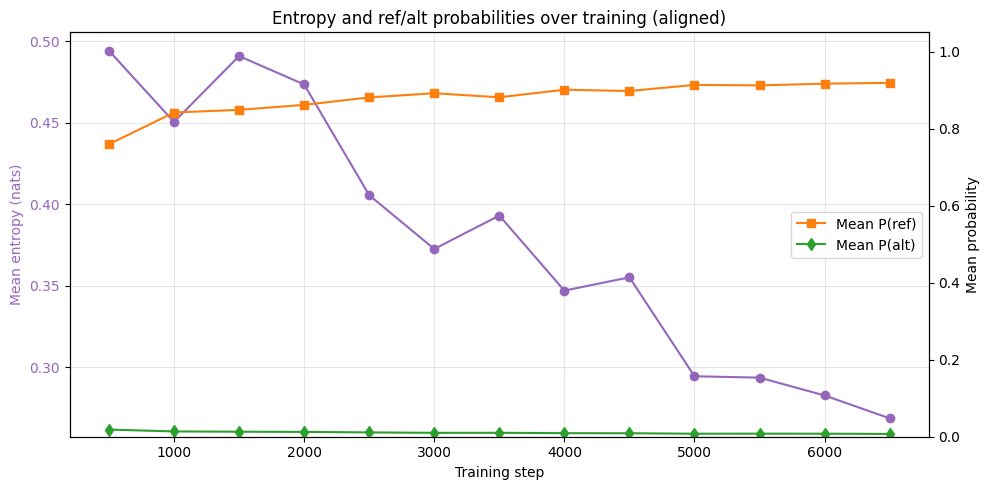

In [26]:
mean_entropy = aligned_clinvar_entropy.groupby("step")["entropy"].mean()
mean_p_ref = aligned_clinvar_entropy.groupby("step")["ref_log_prob"].apply(lambda x: np.exp(x).mean())
mean_p_alt = aligned_clinvar_entropy.groupby("step")["alt_log_prob"].apply(lambda x: np.exp(x).mean())


fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(mean_entropy.index, mean_entropy.values,
         marker="o", color="tab:purple", label="Mean entropy (left axis)")
ax1.set_xlabel("Training step")
ax1.set_ylabel("Mean entropy (nats)", color="tab:purple")
ax1.tick_params(axis="y", labelcolor="tab:purple")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(mean_p_ref.index, mean_p_ref.values,
         marker="s", color="tab:orange", label="Mean P(ref)")
ax2.plot(mean_p_alt.index, mean_p_alt.values,
         marker="d", color="tab:green", label="Mean P(alt)")
ax2.set_ylabel("Mean probability", color="black")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="center right")

plt.title("Entropy and ref/alt probabilities over training (aligned)")
fig.tight_layout()
plt.show()

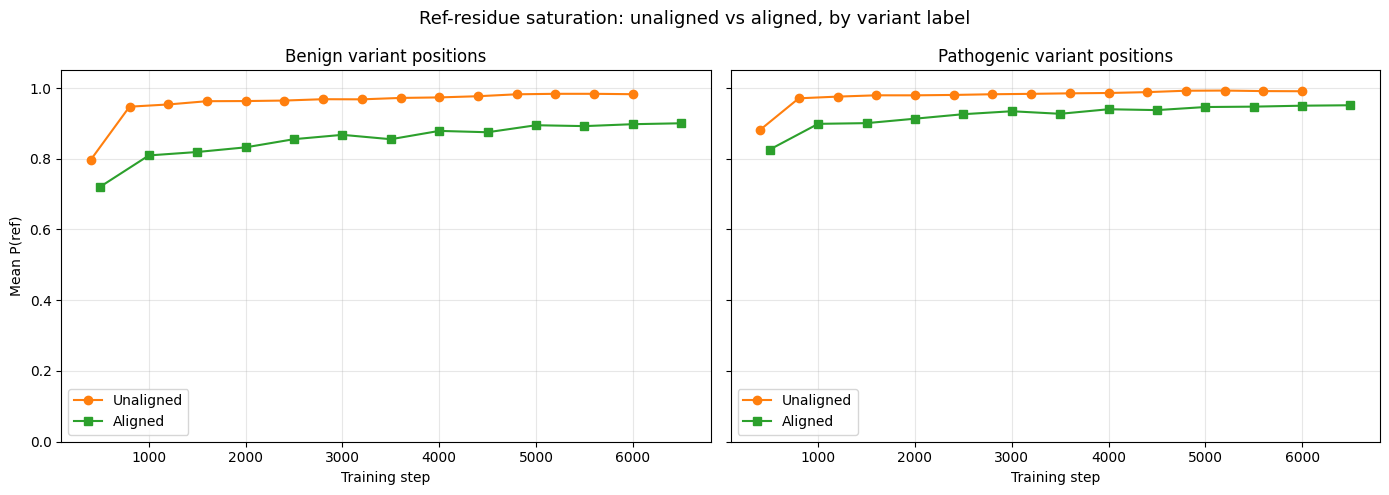

In [30]:
def get_mean_pref(df, label):
    sub = df[(df["scored"]) & (df["label"] == label)]
    return sub.groupby("step")["ref_log_prob"].apply(lambda x: np.exp(x).mean())

# Compute per-label P(ref) for both models
unaligned_pref_benign = get_mean_pref(unaligned_clinvar_entropy, 0)
unaligned_pref_pathogenic = get_mean_pref(unaligned_clinvar_entropy, 1)
aligned_pref_benign = get_mean_pref(aligned_clinvar_entropy, 0)
aligned_pref_pathogenic = get_mean_pref(aligned_clinvar_entropy, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Benign panel
axes[0].plot(unaligned_pref_benign.index, unaligned_pref_benign.values,
             marker="o", label="Unaligned", color="tab:orange")
axes[0].plot(aligned_pref_benign.index, aligned_pref_benign.values,
             marker="s", label="Aligned", color="tab:green")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Mean P(ref)")
axes[0].set_title("Benign variant positions")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pathogenic panel
axes[1].plot(unaligned_pref_pathogenic.index, unaligned_pref_pathogenic.values,
             marker="o", label="Unaligned", color="tab:orange")
axes[1].plot(aligned_pref_pathogenic.index, aligned_pref_pathogenic.values,
             marker="s", label="Aligned", color="tab:green")
axes[1].set_xlabel("Training step")
axes[1].set_title("Pathogenic variant positions")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Ref-residue saturation: unaligned vs aligned, by variant label", fontsize=13)
fig.tight_layout()
plt.show()

# # Print summary table
# summary = pd.DataFrame({
#     "unaligned_benign": unaligned_pref_benign,
#     "unaligned_pathogenic": unaligned_pref_pathogenic,
#     "aligned_benign": aligned_pref_benign,
#     "aligned_pathogenic": aligned_pref_pathogenic,
# })
# print(summary.round(4))


=== Unaligned — benign variants ===
      mean_entropy  mean_p_ref  mean_p_alt
step                                      
400         0.6306      0.7972      0.0195
800         0.2701      0.9472      0.0098
1200        0.2436      0.9535      0.0091
1600        0.2049      0.9627      0.0078
2000        0.2094      0.9631      0.0077
2400        0.2007      0.9646      0.0076
2800        0.1808      0.9684      0.0067
3200        0.1821      0.9680      0.0070
3600        0.1635      0.9720      0.0061
4000        0.1520      0.9734      0.0055
4400        0.1352      0.9768      0.0049
4800        0.0992      0.9823      0.0038
5200        0.0922      0.9836      0.0034
5600        0.0989      0.9836      0.0033
6000        0.1025      0.9825      0.0035

=== Unaligned — pathogenic variants ===
      mean_entropy  mean_p_ref  mean_p_alt
step                                      
400         0.4374      0.8817      0.0078
800         0.1763      0.9709      0.0033
1200        0.1509 

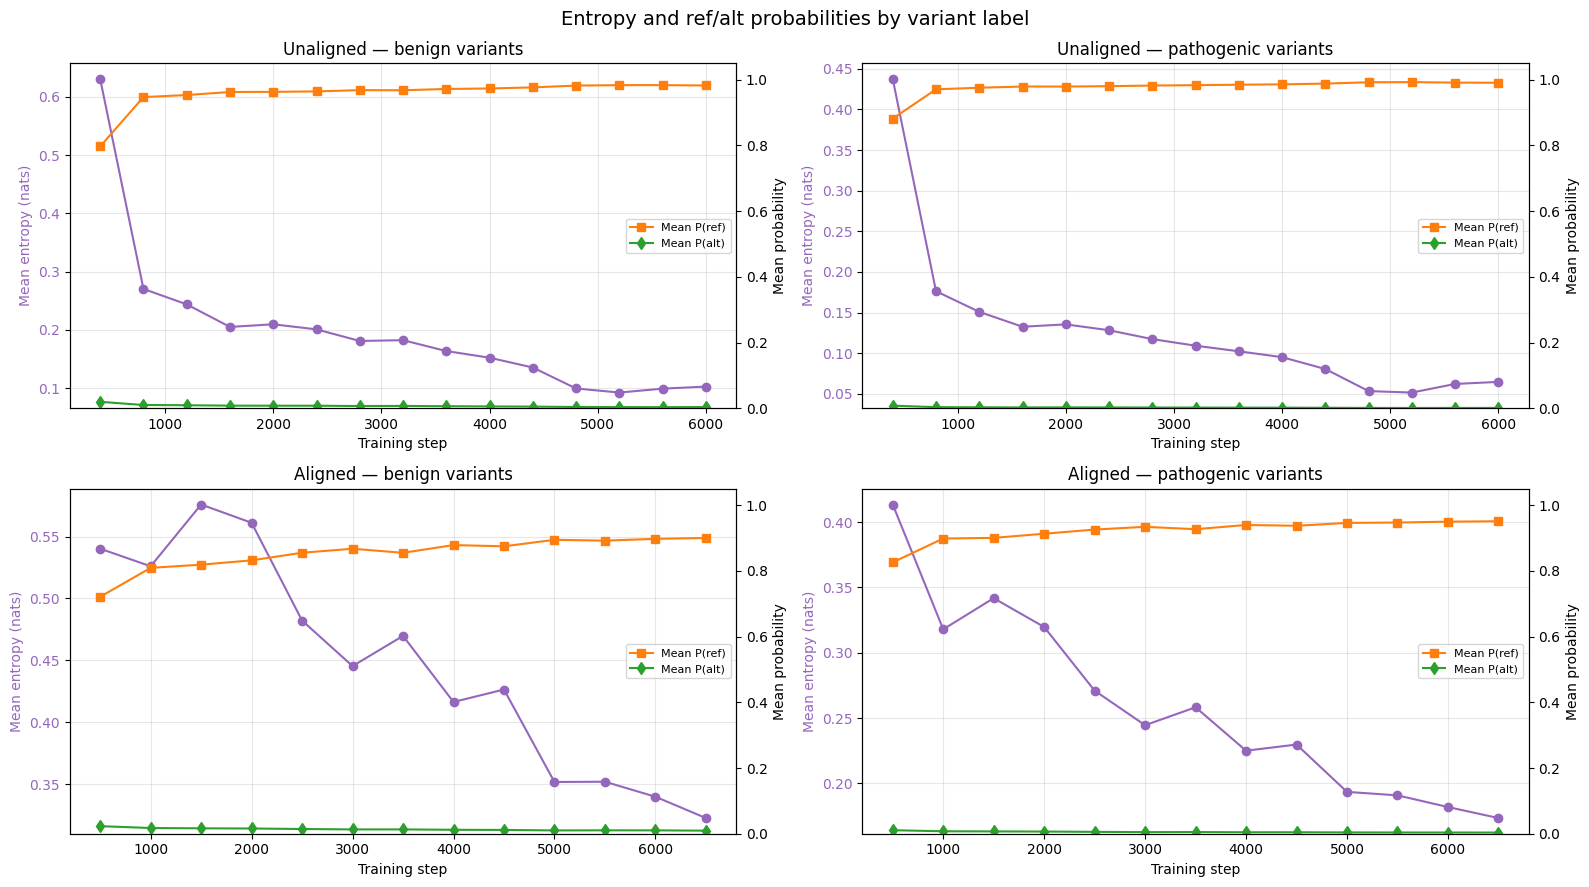

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_entropy_pref_palt(df, model_name, ax_benign, ax_pathogenic):
    """Plot entropy + P(ref) + P(alt) over training, separately for each label.
    Also prints a summary table per panel."""
    df = df[df["scored"]].copy()
    df["p_ref"] = np.exp(df["ref_log_prob"])
    df["p_alt"] = np.exp(df["alt_log_prob"])

    summaries = {}

    for label, ax in [(0, ax_benign), (1, ax_pathogenic)]:
        sub = df[df["label"] == label]
        mean_entropy = sub.groupby("step")["entropy"].mean()
        mean_p_ref = sub.groupby("step")["p_ref"].mean()
        mean_p_alt = sub.groupby("step")["p_alt"].mean()

        ax.plot(mean_entropy.index, mean_entropy.values,
                marker="o", color="tab:purple", label="Mean entropy")
        ax.set_xlabel("Training step")
        ax.set_ylabel("Mean entropy (nats)", color="tab:purple")
        ax.tick_params(axis="y", labelcolor="tab:purple")
        ax.grid(True, alpha=0.3)

        ax_twin = ax.twinx()
        ax_twin.plot(mean_p_ref.index, mean_p_ref.values,
                     marker="s", color="tab:orange", label="Mean P(ref)")
        ax_twin.plot(mean_p_alt.index, mean_p_alt.values,
                     marker="d", color="tab:green", label="Mean P(alt)")
        ax_twin.set_ylabel("Mean probability", color="black")
        ax_twin.set_ylim(0, 1.05)
        ax_twin.legend(loc="center right", fontsize=8)

        label_name = "benign" if label == 0 else "pathogenic"
        ax.set_title(f"{model_name} — {label_name} variants")

        # Build summary table for this panel
        summary = pd.DataFrame({
            "mean_entropy": mean_entropy,
            "mean_p_ref": mean_p_ref,
            "mean_p_alt": mean_p_alt,
        })
        summaries[label_name] = summary

        print(f"\n=== {model_name} — {label_name} variants ===")
        print(summary.round(4))

    return summaries


# Build a 2x2 grid: rows = model, columns = label
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

unaligned_summaries = plot_entropy_pref_palt(
    unaligned_clinvar_entropy, "Unaligned",
    ax_benign=axes[0, 0], ax_pathogenic=axes[0, 1],
)
aligned_summaries = plot_entropy_pref_palt(
    aligned_clinvar_entropy, "Aligned",
    ax_benign=axes[1, 0], ax_pathogenic=axes[1, 1],
)

fig.suptitle("Entropy and ref/alt probabilities by variant label", fontsize=14)
fig.tight_layout()
plt.show()

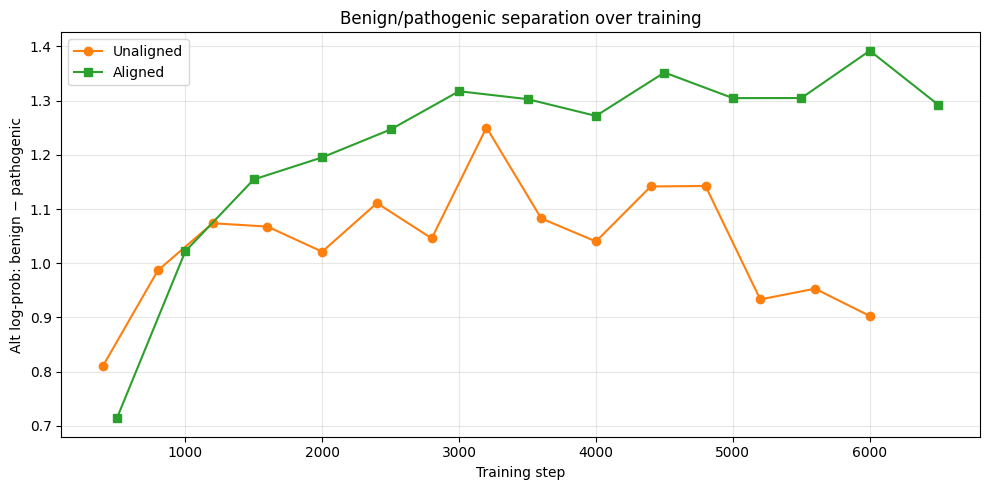

In [20]:
import pandas as pd
import matplotlib.pyplot as plt


def alt_gap(df):
    benign     = df[df["label"] == 0].groupby("step")["alt_log_prob"].mean()
    pathogenic = df[df["label"] == 1].groupby("step")["alt_log_prob"].mean()
    return benign - pathogenic

unaligned_gap = alt_gap(unaligned_clinvar_entropy)
aligned_gap   = alt_gap(aligned_clinvar_entropy)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(unaligned_gap.index, unaligned_gap.values,
        marker="o", label="Unaligned", color="tab:orange")
ax.plot(aligned_gap.index, aligned_gap.values,
        marker="s", label="Aligned", color="tab:green")
ax.set_xlabel("Training step")
ax.set_ylabel("Alt log-prob: benign − pathogenic")
ax.set_title("Benign/pathogenic separation over training")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()